# Support Vector Regression (SVR)

---

## 1. Why Not Just Use Linear Regression?

Linear regression minimizes the **sum of squared errors**:

$$\mathcal{L}_{\text{OLS}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- $x_i \in \mathbb{R}^d$ — input feature vector for sample $i$ ($d$ features)
- $y_i \in \mathbb{R}$ — true target value
- $\hat{y}_i$ — predicted value
- $w \in \mathbb{R}^d$ — weight vector; one weight per feature
- $b \in \mathbb{R}$ — bias (intercept)

**The problem:** squaring errors makes large errors explode. One outlier with error $= 50$ contributes $2500$ to the loss — it can drag the entire regression line toward itself.

**SVR's answer:** *"If the prediction is close enough, don't penalize it at all."*

---

## 2. The $\varepsilon$-Insensitive Loss

SVR defines a **dead zone** of width $\varepsilon$ around the prediction. Errors within this zone cost nothing:

$$L_\varepsilon(y, f(x)) = \max\!\left(0,\ |y - f(x)| - \varepsilon\right)$$

- $\varepsilon > 0$ — tube half-width; a hyperparameter you choose
- $|y - f(x)|$ — absolute prediction error

| Region | Condition | Penalty |
|--------|-----------|---------|
| Inside tube | $\|y - f(x)\| \leq \varepsilon$ | $0$ |
| Outside tube | $\|y - f(x)\| > \varepsilon$ | $\|y - f(x)\| - \varepsilon$ (linear) |

OLS penalizes quadratically everywhere. SVR ignores small errors and penalizes large ones **linearly** — so outliers influence the model much less aggressively. SVR is not *immune* to outliers, just *less sensitive*.

| Model | Loss growth | Robust? |
|-------|-------------|---------|
| Linear Regression | Quadratic | No |
| SVR | Linear beyond $\varepsilon$ | More robust |
| Huber Regression | Quadratic then linear | Yes |

---

## 3. The $\varepsilon$-Tube: Geometric Picture

Draw the regression line $f(x) = w^T x + b$, then draw two parallel lines at distance $\varepsilon$:

$$\text{Upper boundary: } f(x) + \varepsilon \qquad \text{Lower boundary: } f(x) - \varepsilon$$

- Points **inside** the tube → zero loss, ignored entirely
- Points **on the boundary** → these become **Support Vectors**
- Points **outside** the tube → penalized by how far they exceed the boundary

The model only depends on the support vectors. All interior points are irrelevant to the final solution — this is what makes SVR **sparse**.

---

## 4. "Flat Function" and $\|w\|$

SVR also wants the regression function to be as **flat** (smooth) as possible.

**Flat does not mean slope = 0.** It means the weight vector is small in magnitude.

In 1D, $f(x) = wx + b$:
- Large $w$ → steep slope → sensitive to input changes → overfits
- Small $w$ → gentle slope → generalizes better

$\|w\|$ is the **L2 norm** (Euclidean length) of the weight vector:

$$\|w\| = \sqrt{\sum_{j=1}^{d} w_j^2}, \qquad \|w\|^2 = w^T w = \sum_{j=1}^{d} w_j^2$$

We minimize $\|w\|^2$ (not $\|w\|$) because it is differentiable and easier to optimize — the minimizer is the same either way.

This is identical in spirit to **Ridge Regression's** $\lambda\|w\|^2$ penalty: both discourage large weights and prevent overfitting.

---

## 5. The Primal Optimization Problem

SVR wants $f(x) = w^T x + b$ that is flat **and** keeps errors within $\varepsilon$.

### Constraints

$$y_i - w^T x_i - b \leq \varepsilon \quad \text{(true value not too far above prediction)}$$
$$w^T x_i + b - y_i \leq \varepsilon \quad \text{(true value not too far below prediction)}$$

Together these enforce $|y_i - f(x_i)| \leq \varepsilon$ for all $i$.

### Slack Variables

When some points inevitably fall outside the tube, enforcing hard constraints makes the problem **infeasible**. We relax them with **slack variables**:

$$\xi_i \geq 0 \quad \text{— how far point } i \text{ exceeds the upper boundary}$$
$$\xi_i^* \geq 0 \quad \text{— how far point } i \text{ falls below the lower boundary}$$

Geometrically:

$$\xi_i = y_i - (f(x_i) + \varepsilon) \quad \text{when point is above upper boundary}$$
$$\xi_i^* = (f(x_i) - \varepsilon) - y_i \quad \text{when point is below lower boundary}$$
$$\xi_i = \xi_i^* = 0 \quad \text{when point is inside the tube}$$

At most one of $\xi_i, \xi_i^*$ is nonzero for any given point — a point cannot violate both boundaries simultaneously. SVM classification uses one slack per point; SVR needs **two** because errors can go in either direction.

### Full Primal Problem

$$\min_{w,\, b,\, \xi_i,\, \xi_i^*} \quad \underbrace{\frac{1}{2}\|w\|^2}_{\text{flatness}} + \underbrace{C \sum_{i=1}^{n}(\xi_i + \xi_i^*)}_{\text{total violation}}$$

subject to:

$$y_i - w^T x_i - b \leq \varepsilon + \xi_i, \quad w^T x_i + b - y_i \leq \varepsilon + \xi_i^*, \quad \xi_i, \xi_i^* \geq 0$$

- $C > 0$ — **regularization parameter**; controls the tradeoff between flatness and fitting

| $C$ | Effect |
|-----|--------|
| Large | Violations punished heavily → fits tightly → risk of overfitting |
| Small | Violations tolerated → smoother function → risk of underfitting |

This is a **convex quadratic program** — it has a unique global minimum.

---

## 6. Dual Formulation and Lagrange Multipliers

To solve efficiently and unlock the kernel trick, we convert to the **dual problem** using Lagrange multipliers.

Attaching multipliers $\alpha_i, \alpha_i^* \geq 0$ to each constraint and taking derivatives gives the **KKT stationarity conditions**:

$$\frac{\partial \mathcal{L}}{\partial w} = 0 \implies w = \sum_{i=1}^{n}(\alpha_i - \alpha_i^*)\, x_i$$

$$\frac{\partial \mathcal{L}}{\partial b} = 0 \implies \sum_{i=1}^{n}(\alpha_i - \alpha_i^*) = 0$$

$$\frac{\partial \mathcal{L}}{\partial \xi_i} = 0 \implies \alpha_i \in [0, C], \quad \frac{\partial \mathcal{L}}{\partial \xi_i^*} = 0 \implies \alpha_i^* \in [0, C]$$

**Key insight from the first equation:** $w$ is entirely a linear combination of training points weighted by $(\alpha_i - \alpha_i^*)$. Substituting back gives the **dual problem**:

$$\max_{\alpha_i,\, \alpha_i^*} \quad -\frac{1}{2}\sum_{i,j}(\alpha_i - \alpha_i^*)(\alpha_j - \alpha_j^*)\, x_i^T x_j - \varepsilon\sum_{i}(\alpha_i + \alpha_i^*) + \sum_{i} y_i(\alpha_i - \alpha_i^*)$$

subject to:

$$\sum_{i}(\alpha_i - \alpha_i^*) = 0, \qquad 0 \leq \alpha_i,\, \alpha_i^* \leq C$$

- $\alpha_i, \alpha_i^*$ — **dual variables** (Lagrange multipliers), one pair per training point
- $x_i^T x_j$ — dot product between training points $i$ and $j$; this is what the kernel replaces

### Prediction in Dual Form

Since $w = \sum_i (\alpha_i - \alpha_i^*) x_i$, the prediction becomes:

$$f(x) = w^T x + b = \sum_{i=1}^{n}(\alpha_i - \alpha_i^*)\, x_i^T x + b$$

Notice: $w$ has **disappeared**. Prediction now depends only on dot products between the new point $x$ and each training point $x_i$.

By KKT complementary slackness, most $(\alpha_i - \alpha_i^*) = 0$ — only points on or outside the tube boundary survive:

| Point location | $\alpha_i - \alpha_i^*$ | Role |
|----------------|------------------------|------|
| Strictly inside tube | $= 0$ | Not a support vector |
| On tube boundary | $\neq 0$, $< C$ | **Support vector** |
| Outside tube | $= C$ or $-C$ | **Support vector** (with slack) |

The model is built entirely from support vectors — hence the name.

---

## 7. The Kernel Trick

The dual prediction only uses dot products $x_i^T x$. A dot product measures **alignment / similarity** between two vectors — so SVR prediction is literally a weighted sum of similarities between the new point and the training points.

**The problem:** for nonlinear data, we'd need to map inputs to a higher-dimensional space $\phi(x)$ where the relationship becomes linear — but computing $\phi(x_i)^T \phi(x)$ can be extremely expensive.

**The trick:** define a kernel function that computes the dot product in the transformed space *without ever computing $\phi$*:

$$K(x_i, x) = \phi(x_i)^T \phi(x)$$

Simply replace every $x_i^T x$ with $K(x_i, x)$. The prediction becomes:

$$\boxed{f(x) = \sum_{i \in SV}(\alpha_i - \alpha_i^*)\, K(x_i, x) + b}$$

$$f(x) = \sum_{i} \underbrace{(\alpha_i - \alpha_i^*)}_{\text{learned weight}} \times \underbrace{K(x_i, x)}_{\text{similarity to } x_i}$$

Instead of learning weights for **features**, SVR learns weights for **training points**. Each support vector says: *"if the new input is similar to me, I contribute this much to the prediction."*

### Common Kernels

| Kernel | Formula | Notes |
|--------|---------|-------|
| Linear | $x_i^T x$ | No transformation |
| Polynomial | $(x_i^T x + c)^p$ | Degree $p$, coefficient $c > 0$ |
| RBF / Gaussian | $\exp(-\gamma \|x_i - x\|^2)$ | Most widely used |
| Sigmoid | $\tanh(\kappa\, x_i^T x + \theta)$ | Neural network-like |

### RBF (Radial Basis Function) Kernel in Detail

$$K(x_i, x) = \exp\!\left(-\gamma\, \|x_i - x\|^2\right), \qquad \|x_i - x\|^2 = \sum_{j=1}^{d}(x_{ij} - x_j)^2$$

- $\gamma > 0$ — controls how quickly influence drops with distance
- Small distance → $K \approx 1$ → strong influence
- Large distance → $K \approx 0$ → almost no influence

Think of each support vector as a **Gaussian bump** centered at that point. The SVR prediction is a weighted sum of these bumps — which is how it fits complex nonlinear shapes.

| $\gamma$ | Effect |
|----------|--------|
| Large | Narrow bumps → complex, local model → risk of overfitting |
| Small | Wide bumps → smooth, global model → risk of underfitting |

> **Without kernel** → SVR is linear regression with $\varepsilon$-insensitive loss.  
> **With kernel** → SVR is a nonlinear function approximator operating in (possibly infinite-dimensional) feature space at minimal cost.

---

## 8. Computing the Bias $b$

After solving for $\alpha_i, \alpha_i^*$, compute $b$ from any support vector strictly on the tube boundary:

- If $0 < \alpha_i < C$ (on upper boundary, $y_i - f(x_i) = \varepsilon$):
$$b = y_i - \sum_{j \in SV}(\alpha_j - \alpha_j^*)\, K(x_j, x_i) - \varepsilon$$

- If $0 < \alpha_i^* < C$ (on lower boundary, $f(x_i) - y_i = \varepsilon$):
$$b = y_i - \sum_{j \in SV}(\alpha_j - \alpha_j^*)\, K(x_j, x_i) + \varepsilon$$

In practice, $b$ is averaged over all boundary support vectors for numerical stability.

---

## 9. Hyperparameters

| Parameter | Symbol | Effect |
|-----------|--------|--------|
| Regularization | $C$ | ↑ fits tighter, ↓ smoother |
| Tube width | $\varepsilon$ | ↑ more tolerance, fewer support vectors |
| Kernel bandwidth | $\gamma$ | ↑ local/complex, ↓ smooth/global |
| Kernel type | — | Determines what "similarity" means |

---

## 10. SVR vs Linear Regression

| Aspect | Linear Regression | SVR |
|--------|------------------|-----|
| Loss | Squared (quadratic) | $\varepsilon$-insensitive (linear beyond $\varepsilon$) |
| Outlier sensitivity | High | Lower |
| Nonlinearity | No | Yes, via kernel |
| Sparsity | No | Yes (only support vectors) |
| Interpretability | High | Low for nonlinear kernels |
| Complexity | $O(nd)$ | $O(n^2)$ to $O(n^3)$ |

**Use SVR when:** dataset is small/medium, data has outliers, relationship is nonlinear, sparse model is desired.  
**Avoid SVR when:** dataset is very large ($n \gtrsim 10{,}000$), fast training is needed, interpretability matters.

---

## 11. Full Roadmap

$$\underbrace{\min\; \frac{1}{2}\|w\|^2 + C\sum(\xi_i + \xi_i^*)}_{\text{Primal: flatness + penalized violations}}$$

$$\Downarrow \text{ Lagrangian + KKT}$$

$$\underbrace{\max\; \left[-\frac{1}{2}\sum_{i,j}(\alpha_i-\alpha_i^*)(\alpha_j-\alpha_j^*)K(x_i,x_j) - \varepsilon\sum(\alpha_i+\alpha_i^*) + \sum y_i(\alpha_i-\alpha_i^*)\right]}_{\text{Dual: solve for } \alpha_i, \alpha_i^*}$$

$$\Downarrow \text{ kernel substitution}$$

$$\underbrace{f(x) = \sum_{i \in SV}(\alpha_i - \alpha_i^*)\,K(x_i, x) + b}_{\text{sparse prediction: only support vectors contribute}}$$

> **One-line summary:**  
> $\text{SVR} = \text{Ridge Regression} + \varepsilon\text{-Insensitive Loss} + \text{Kernel Trick}$

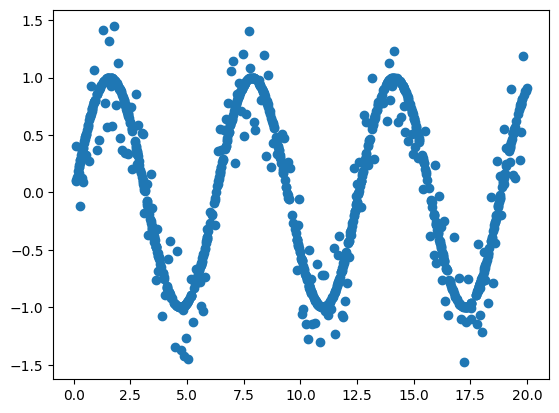

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 1. Generate synthetic data
# -----------------------------
np.random.seed(42)
X = np.sort(20 * np.random.rand(1000, 1), axis=0)
y = np.sin(X).ravel()

# Add noise
y[::5] += 0.5 - np.random.rand(200)

plt.scatter(X,y)

In [32]:
# -----------------------------
# 2. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
# -----------------------------
# 3. Fit SVR Model
# -----------------------------
svr_rbf = SVR(kernel='rbf', C=200, epsilon=0.1, gamma=0.5)
svr_rbf.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.5
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",200
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [41]:
# -----------------------------
# 4. Prediction
# -----------------------------
y_pred = svr_rbf.predict(X_test)

# -----------------------------
# 5. Evaluation Metrics
# -----------------------------
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Squared Error: 0.024090547310153324
Mean Absolute Error: 0.10880987220320276
R2 Score: 0.9509430529641761


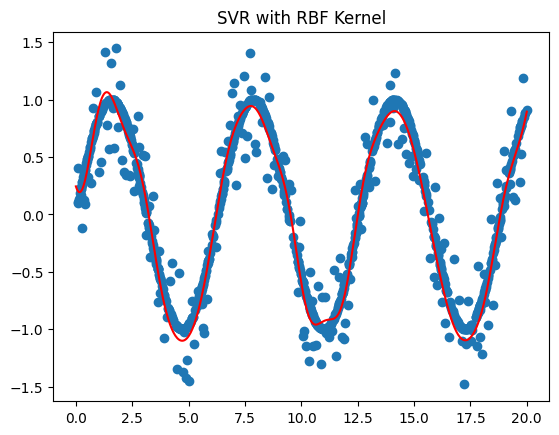

In [42]:
# -----------------------------
# 6. Visualization
# -----------------------------
X_range = np.linspace(0, 20, 500).reshape(-1, 1)
y_range_pred = svr_rbf.predict(X_range)

plt.scatter(X, y, label="Data")
plt.plot(X_range, y_range_pred, color="red")
plt.title("SVR with RBF Kernel")
plt.show()